In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, log_loss

# reproducibility
SEED = 42
np.random.seed(SEED)

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Data Pipeline

In [3]:
# loading and preparing the ionosphere dataset
data = fetch_openml(name="ionosphere", version=1, as_frame=True)

X = data.data.to_numpy(dtype=float)
y = data.target.to_numpy()

y = np.where(y == "g", 1, 0)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

Dataset shape: (351, 34)
Class distribution: [126 225]


In [4]:
# perform a 70/30 split to create a training and test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

print("Training pool shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Training pool shape: (245, 34)
Test shape: (106, 34)


# Model Implementation

## Logistic Regression

In [5]:
# training function for logistic regression
def train_logistic(X_train, y_train):
    model = LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        fit_intercept=True,
        random_state=SEED
    )
    model.fit(X_train, y_train)
    return model

# evaluation function for logistic regression
def evaluate_logistic(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # cross-entropy loss
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    # generalization gap
    gap = train_acc - test_acc

    return train_acc, test_acc, train_loss, test_loss, gap

## LDA

In [6]:
# training function for linear discriminant analysis
def train_lda(X_train, y_train):
    model = LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto")
    model.fit(X_train, y_train)
    return model

# evaluation function for linear discriminant analysis
def evaluate_lda(model, X_train, y_train, X_test, y_test):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        y_train_pred = model.predict(X_train)
        y_test_pred  = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)
        y_test_prob  = model.predict_proba(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)
    train_loss = log_loss(y_train, y_train_prob)
    test_loss  = log_loss(y_test,  y_test_prob)
    gap = train_acc - test_acc

    return train_acc, test_acc, train_loss, test_loss, gap

# Experiments

## Varying Sample Size (N) and Measuring Performance

In [7]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 1: Varying Sample Size (N), Fixed M=34
# ─────────────────────────────────────────────────────────────

sample_fracs = np.linspace(0.1, 1.0, 10)
results_n = []

for i, frac in enumerate(sample_fracs):
    n = max(int(frac * len(X_train_full)), 2)

    rng = np.random.default_rng(SEED + i)

    idx = []
    for cls in np.unique(y_train_full):
        cls_idx = np.where(y_train_full == cls)[0]
        k = max(1, round(n * len(cls_idx) / len(y_train_full)))
        k = min(k, len(cls_idx))
        idx.extend(rng.choice(cls_idx, size=k, replace=False))

    idx = np.array(idx)
    rng.shuffle(idx)

    X_sub = X_train_full[idx]
    y_sub = y_train_full[idx]

    scaler_n = StandardScaler()
    X_sub_sc = scaler_n.fit_transform(X_sub)
    X_test_sc_n = scaler_n.transform(X_test)

    lr = train_logistic(X_sub_sc, y_sub)
    lda = train_lda(X_sub_sc, y_sub)

    lr_metrics = evaluate_logistic(lr, X_sub_sc, y_sub, X_test_sc_n, y_test)
    lda_metrics = evaluate_lda(lda, X_sub_sc, y_sub, X_test_sc_n, y_test)

    results_n.append(dict(
        N=len(idx),
        M=X_sub_sc.shape[1],
        M_over_N=X_sub_sc.shape[1] / len(idx),

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_n = pd.DataFrame(results_n)
print("=== Varying N (stratified, reproducible) ===")
print(df_n.to_string(index=False))

=== Varying N (stratified, reproducible) ===
  N  M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss   lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss   lda_gap
 24 34  1.416667      1.000000     0.783019       0.085868      0.553651 0.216981       0.958333      0.764151        0.091227       1.362721  0.194182
 49 34  0.693878      0.979592     0.858491       0.098599      0.423205 0.121101       0.979592      0.858491        0.119960       0.636430  0.121101
 73 34  0.465753      0.986301     0.839623       0.140433      0.499397 0.146679       0.917808      0.867925        0.232298       0.399567  0.049884
 98 34  0.346939      0.989796     0.905660       0.103468      0.333676 0.084136       0.928571      0.886792        0.204540       0.423117  0.041779
122 34  0.278689      0.942623     0.896226       0.168666      0.314236 0.046397       0.926230      0.905660        0.276924       0.270560  0.020569
147 34  0.231293      0.972789     0.886792

## Varying Feature Dimension (M) and Measuring Performance

### Low-capacity regime with original features

In [8]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 2.1: Varying Feature Dimension (M), Fixed N=245
# Features selected by descending variance rank so each
# increment adds the next most informative original feature
# ─────────────────────────────────────────────────────────────

feature_fracs = np.linspace(0.1, 1.0, 10)
results_m = []

# scale once on full training set — N is fixed so no leakage concern
scaler_m = StandardScaler()
X_train_sc_m = scaler_m.fit_transform(X_train_full)
X_test_sc_m  = scaler_m.transform(X_test)

# rank features by variance on training set (descending)
feature_variances = X_train_sc_m.var(axis=0)
variance_order = np.argsort(feature_variances)[::-1]  # high → low

total_features = X_train_full.shape[1]  # 34

for i, frac in enumerate(feature_fracs):
    m = max(int(frac * total_features), 1)

    # select top-m features by variance
    selected = variance_order[:m]
    X_tr_m = X_train_sc_m[:, selected]
    X_te_m = X_test_sc_m[:, selected]

    lr  = train_logistic(X_tr_m, y_train_full)
    lda = train_lda(X_tr_m, y_train_full)

    lr_metrics  = evaluate_logistic(lr,  X_tr_m, y_train_full, X_te_m, y_test)
    lda_metrics = evaluate_lda(lda,      X_tr_m, y_train_full, X_te_m, y_test)

    results_m.append(dict(
        N=len(y_train_full),
        M=m,
        M_over_N=m / len(y_train_full),

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_m = pd.DataFrame(results_m)
print("=== Varying M by Variance Rank (Fixed N=245) ===")
print(df_m.to_string(index=False))

=== Varying M by Variance Rank (Fixed N=245) ===
  N  M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss    lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss   lda_gap
245  3  0.012245      0.873469     0.915094       0.401504      0.344811 -0.041625       0.873469      0.924528        0.426799       0.344962 -0.051059
245  6  0.024490      0.865306     0.905660       0.381567      0.342009 -0.040354       0.873469      0.886792        0.419269       0.350460 -0.013323
245 10  0.040816      0.873469     0.886792       0.285656      0.300760 -0.013323       0.877551      0.905660        0.345057       0.292095 -0.028109
245 13  0.053061      0.893878     0.896226       0.270748      0.292351 -0.002349       0.865306      0.905660        0.335359       0.295747 -0.040354
245 17  0.069388      0.889796     0.877358       0.248144      0.293489  0.012437       0.869388      0.924528        0.325014       0.285914 -0.055141
245 20  0.081633      0.910204   

### Interpolation-focused regime with polynomial expansion

In [9]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 2.2: Behavior near Interpolation Threshold (M ≈ N)
# Uses degree-2 polynomial expansion to push M past N=245
# Starts at M=35 to avoid overlap with Experiment 2.1
# ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import PolynomialFeatures

# scale first on full training set
scaler_interp = StandardScaler()
X_train_sc_interp = scaler_interp.fit_transform(X_train_full)
X_test_sc_interp  = scaler_interp.transform(X_test)

# degree-2 polynomial expansion: 34 features → 629 features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sc_interp)
X_test_poly  = poly.transform(X_test_sc_interp)

total_poly_features = X_train_poly.shape[1]  # 629
n_train = len(y_train_full)                   # 245

print(f"Expanded feature space: {total_poly_features} features, N={n_train}")
print(f"Interpolation threshold at M={n_train}")

# sweep M starting from 35 (just above original feature space)
# dense sampling around threshold, sparse elsewhere
m_values = sorted(set(
    list(range(35, 100, 15)) +              # just above original features
    list(range(100, 200, 25)) +             # approaching threshold
    list(range(210, 285, 5)) +              # near threshold (dense)
    list(range(300, total_poly_features + 1, 50))  # above threshold
))

results_interp = []

for m in m_values:
    if m > total_poly_features:
        continue

    X_tr_m = X_train_poly[:, :m]
    X_te_m = X_test_poly[:, :m]

    lr  = train_logistic(X_tr_m, y_train_full)
    lda = train_lda(X_tr_m, y_train_full)

    lr_metrics  = evaluate_logistic(lr,  X_tr_m, y_train_full, X_te_m, y_test)
    lda_metrics = evaluate_lda(lda,      X_tr_m, y_train_full, X_te_m, y_test)

    results_interp.append(dict(
        N=n_train,
        M=m,
        M_over_N=m / n_train,

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_interp = pd.DataFrame(results_interp)
print("\n=== Interpolation Threshold (M ≈ N) ===")
print(df_interp.to_string(index=False))

Expanded feature space: 629 features, N=245
Interpolation threshold at M=245

=== Interpolation Threshold (M ≈ N) ===
  N   M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss   lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss   lda_gap
245  35  0.142857      0.942857     0.933962       0.166573      0.312080 0.008895       0.881633      0.924528        0.293380       0.220365 -0.042896
245  50  0.204082      0.942857     0.924528       0.163852      0.358085 0.018329       0.893878      0.933962        0.283517       0.203811 -0.040085
245  65  0.265306      0.942857     0.933962       0.161437      0.334457 0.008895       0.893878      0.943396        0.292945       0.213255 -0.049519
245  80  0.326531      0.942857     0.933962       0.160962      0.332144 0.008895       0.893878      0.943396        0.288602       0.213879 -0.049519
245  95  0.387755      0.942857     0.933962       0.160962      0.332144 0.008895       0.897959      0.943396      

## Results Across Capacity Ratio (M/N)

In [10]:
# ─────────────────────────────────────────────────────────────
# 5.3 Results Across Capacity Ratio (M/N)
# Merges df_n, df_m, df_interp and overlays on shared M/N axis
# Core question: is M/N sufficient to explain generalization?
# ─────────────────────────────────────────────────────────────

# tag each source
df_n_tagged      = df_n.copy();      df_n_tagged["source"]      = "Vary N (fix M=34)"
df_m_tagged      = df_m.copy();      df_m_tagged["source"]      = "Vary M (fix N=245)"
df_interp_tagged = df_interp.copy(); df_interp_tagged["source"] = "Interpolation (poly)"

df_all = pd.concat([df_n_tagged, df_m_tagged, df_interp_tagged], ignore_index=True)
df_all = df_all.sort_values("M_over_N").reset_index(drop=True)

print("=== Combined M/N Table ===")
print(df_all[["source", "N", "M", "M_over_N",
              "lr_test_acc", "lda_test_acc",
              "lr_gap", "lda_gap"]].to_string(index=False))

# df_all is now ready for the Results & Visualization section

=== Combined M/N Table ===
              source   N   M  M_over_N  lr_test_acc  lda_test_acc    lr_gap   lda_gap
  Vary M (fix N=245) 245   3  0.012245     0.915094      0.924528 -0.041625 -0.051059
  Vary M (fix N=245) 245   6  0.024490     0.905660      0.886792 -0.040354 -0.013323
  Vary M (fix N=245) 245  10  0.040816     0.886792      0.905660 -0.013323 -0.028109
  Vary M (fix N=245) 245  13  0.053061     0.896226      0.905660 -0.002349 -0.040354
  Vary M (fix N=245) 245  17  0.069388     0.877358      0.924528  0.012437 -0.055141
  Vary M (fix N=245) 245  20  0.081633     0.896226      0.886792  0.013978 -0.001078
  Vary M (fix N=245) 245  23  0.093878     0.896226      0.896226  0.026223 -0.010512
  Vary M (fix N=245) 245  27  0.110204     0.886792      0.905660  0.035657 -0.015864
  Vary M (fix N=245) 245  30  0.122449     0.905660      0.905660  0.033115 -0.019946
  Vary M (fix N=245) 245  34  0.138776     0.915094      0.896226  0.031844 -0.010512
   Vary N (fix M=34) 245  3

# Results & Visualization

## Performance vs Capacity Ratio (M/N)

In [16]:
# Common smoothing helper
window = 15

def smooth_curve(x, y, window=15):
    df_tmp = pd.DataFrame({"x": x, "y": y}).sort_values("x")
    y_smooth = df_tmp["y"].rolling(window).mean()
    return df_tmp["x"], y_smooth

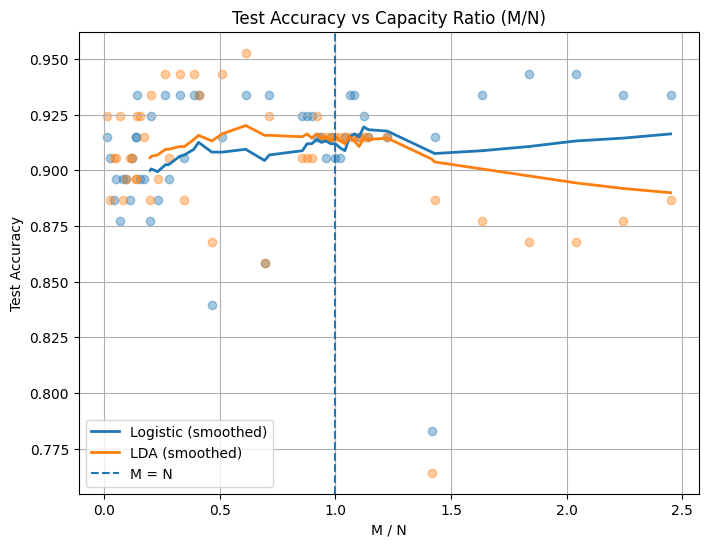

In [17]:
# Performance vs Capacity Ratio (M/N)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_all["M_over_N"], df_all["lr_test_acc"], alpha=0.4)
plt.scatter(df_all["M_over_N"], df_all["lda_test_acc"], alpha=0.4)

# smooth
x_lr, y_lr = smooth_curve(df_all["M_over_N"], df_all["lr_test_acc"], window)
x_lda, y_lda = smooth_curve(df_all["M_over_N"], df_all["lda_test_acc"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Capacity Ratio (M/N)")

plt.legend()
plt.grid(True)
plt.show()

## Generalization Gap across Models

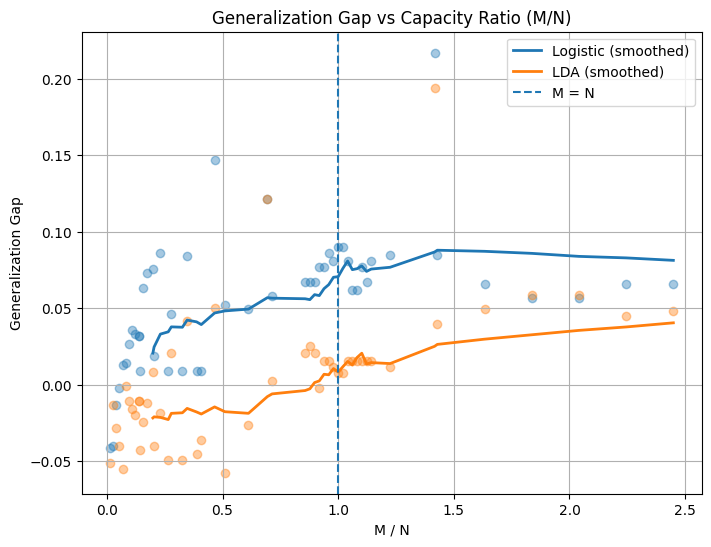

In [18]:
# Generalization Gap across Models

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_all["M_over_N"], df_all["lr_gap"], alpha=0.4)
plt.scatter(df_all["M_over_N"], df_all["lda_gap"], alpha=0.4)

# smooth
x_lr, y_lr = smooth_curve(df_all["M_over_N"], df_all["lr_gap"], window)
x_lda, y_lda = smooth_curve(df_all["M_over_N"], df_all["lda_gap"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Generalization Gap")
plt.title("Generalization Gap vs Capacity Ratio (M/N)")

plt.legend()
plt.grid(True)
plt.show()

## Behavior near Interpolation (M $\approx$ N)

In [14]:
# Behavior near Interpolation (M ≈ N)

df_near = df_all[
    (df_all["M_over_N"] > 0.7) &
    (df_all["M_over_N"] < 1.3)
]

print("Number of points near interpolation:", len(df_near))
df_near.head()

Number of points near interpolation: 17


,N,M,M_over_N,lr_train_acc,lr_test_acc,lr_train_loss,lr_test_loss,lr_gap,lda_train_acc,lda_test_acc,lda_train_loss,lda_test_loss,lda_gap,experiment
27,245,175,0.714286,0.991837,0.933962,0.055653,0.216565,0.057874,0.926531,0.924528,0.325046,0.320209,0.002002,interpolation_region
28,245,210,0.857143,0.991837,0.924528,0.042464,0.221855,0.067308,0.926531,0.905660,0.308362,0.391783,0.020870,interpolation_region
29,245,215,0.877551,0.991837,0.924528,0.042269,0.210653,0.067308,0.930612,0.905660,0.317739,0.410302,0.024952,interpolation_region
30,245,220,0.897959,0.991837,0.924528,0.042190,0.216699,0.067308,0.926531,0.905660,0.319719,0.404965,0.020870,interpolation_region
31,245,225,0.918367,0.991837,0.915094,0.039636,0.269653,0.076742,0.922449,0.924528,0.315046,0.437904,-0.002079,interpolation_region


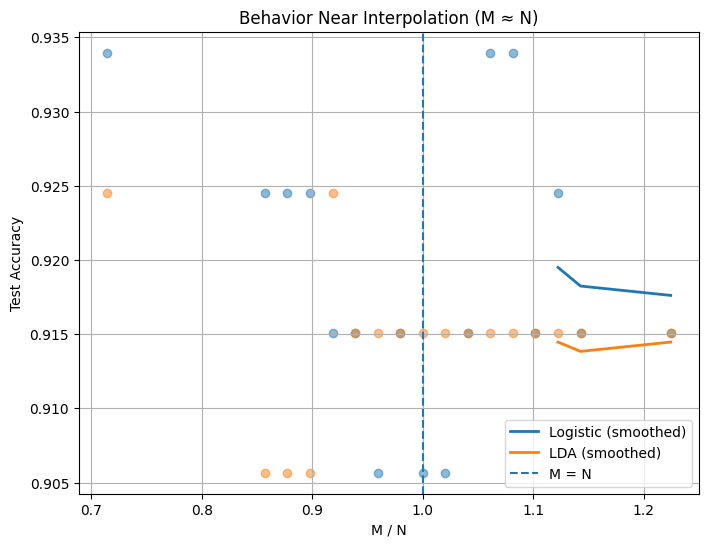

In [19]:
import matplotlib.pyplot as plt

# subset near interpolation
df_near = df_all[
    (df_all["M_over_N"] > 0.7) &
    (df_all["M_over_N"] < 1.3)
]

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_near["M_over_N"], df_near["lr_test_acc"], alpha=0.5)
plt.scatter(df_near["M_over_N"], df_near["lda_test_acc"], alpha=0.5)

# smooth
x_lr, y_lr = smooth_curve(df_near["M_over_N"], df_near["lr_test_acc"], window)
x_lda, y_lda = smooth_curve(df_near["M_over_N"], df_near["lda_test_acc"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Test Accuracy")
plt.title("Behavior Near Interpolation (M ≈ N)")

plt.legend()
plt.grid(True)
plt.show()

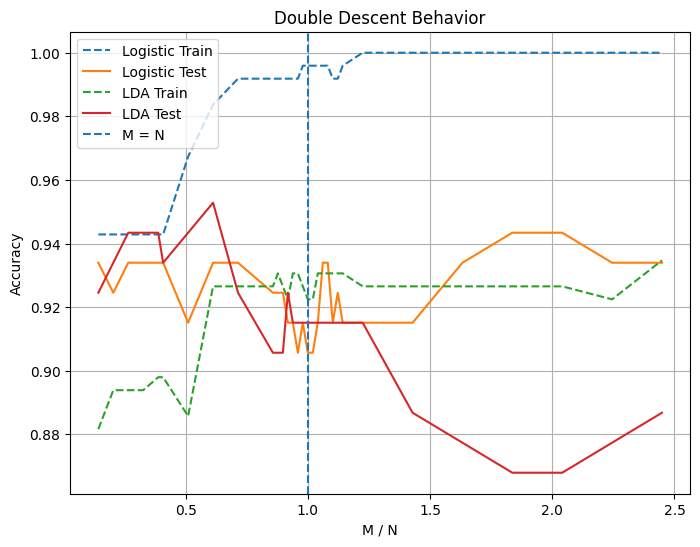

In [20]:
# Double Descent Behavior (Train vs Test)

plt.figure(figsize=(8,6))

# Logistic
plt.plot(df_interp["M_over_N"], df_interp["lr_train_acc"],
         linestyle="--", label="Logistic Train")

plt.plot(df_interp["M_over_N"], df_interp["lr_test_acc"],
         label="Logistic Test")

# LDA
plt.plot(df_interp["M_over_N"], df_interp["lda_train_acc"],
         linestyle="--", label="LDA Train")

plt.plot(df_interp["M_over_N"], df_interp["lda_test_acc"],
         label="LDA Test")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Accuracy")
plt.title("Double Descent Behavior")

plt.legend()
plt.grid(True)

plt.show()